# 11 - Regularization Deep Dive

This notebook studies regularization from first principles and connects it back to EnergyTypeNet. EnergyTypeNet remains the primary dataset. Synthetic data is used only where controlled geometry or known sparse coefficients make the concept easier to verify.

In [4]:
import os
import sys

sys.path.insert(0, os.path.abspath('..'))

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification, make_regression
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import ElasticNet, Lasso, LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from src.data import load_raw
from src.models import (
    ElasticNetCustom,
    LassoRegressionCustom,
    RegularizedLogisticRegression,
    RidgeRegressionCustom,
)

warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42

## 1. Why Regularization Matters

Flexible models can fit training data closely while generalizing poorly. Regularization adds a penalty to the objective function so the model has to trade off fit quality against parameter size or sparsity.

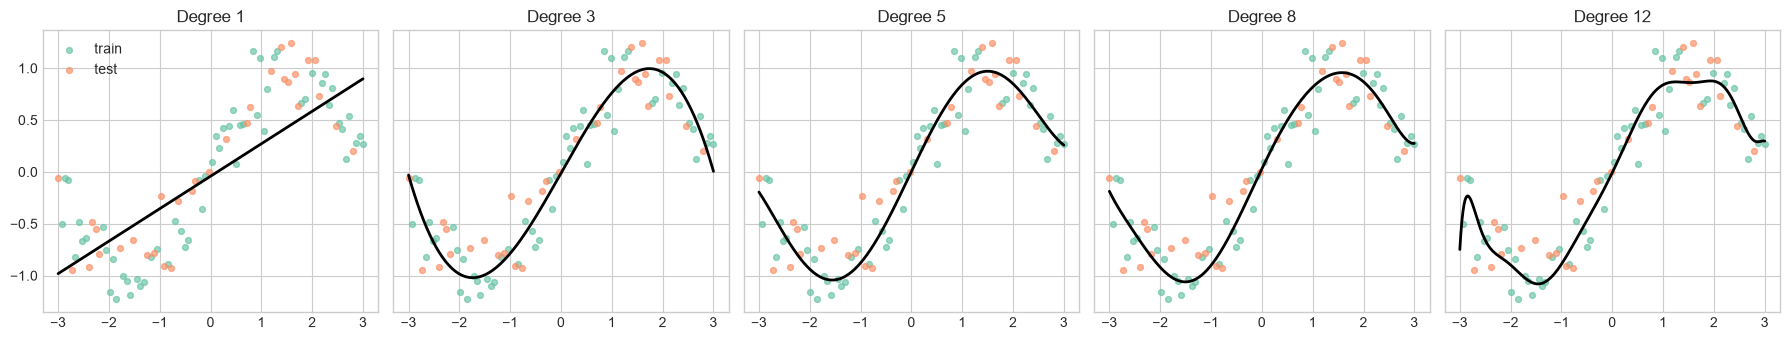

,degree,train_mse,test_mse
0,1,0.207258,0.179948
1,3,0.044446,0.053676
2,5,0.037635,0.058028
3,8,0.037325,0.058378
4,12,0.035824,0.079121


In [5]:
rng = np.random.default_rng(RANDOM_STATE)
X = np.linspace(-3, 3, 90).reshape(-1, 1)
y_true = np.sin(X[:, 0])
y = y_true + rng.normal(0, 0.28, size=X.shape[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=RANDOM_STATE)

degrees = [1, 3, 5, 8, 12]
rows = []
xx = np.linspace(-3, 3, 300).reshape(-1, 1)
fig, axes = plt.subplots(1, len(degrees), figsize=(18, 3.5), sharey=True)

for ax, degree in zip(axes, degrees):
    pipe = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), StandardScaler(), Ridge(alpha=0.0))
    pipe.fit(X_train, y_train)
    rows.append({
        'degree': degree,
        'train_mse': mean_squared_error(y_train, pipe.predict(X_train)),
        'test_mse': mean_squared_error(y_test, pipe.predict(X_test)),
    })
    ax.scatter(X_train[:, 0], y_train, s=18, alpha=0.65, label='train')
    ax.scatter(X_test[:, 0], y_test, s=18, alpha=0.65, label='test')
    ax.plot(xx[:, 0], pipe.predict(xx), color='black', lw=2)
    ax.set_title(f'Degree {degree}')

axes[0].legend()
plt.tight_layout()
plt.show()
pd.DataFrame(rows)

## Observation: Polynomial overfitting

The degree-3 polynomial gives the best test MSE in this run (`0.0537`), while degree 12 has the lowest training MSE but a much worse test MSE (`0.0791`). This is the classic overfitting pattern: the more flexible model fits the training sample better, but generalizes worse because it begins to fit noise instead of only the underlying trend.

## 2. Ridge, Lasso and ElasticNet on Controlled Regression Data

This synthetic regression task has a known sparse signal, so it is useful for checking whether Lasso and ElasticNet recover compact coefficient patterns.

In [6]:
X_reg, y_reg, coef_true = make_regression(
    n_samples=500, n_features=18, n_informative=5, noise=14.0, coef=True, random_state=RANDOM_STATE
)
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.25, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

models = {
    'Ridge custom': RidgeRegressionCustom(alpha=1.0),
    'Ridge sklearn': Ridge(alpha=1.0),
    'Lasso custom': LassoRegressionCustom(alpha=0.04, max_iter=5000, tol=1e-7),
    'Lasso sklearn': Lasso(alpha=0.04, max_iter=5000, tol=1e-7),
    'ElasticNet custom': ElasticNetCustom(alpha=0.04, l1_ratio=0.5, max_iter=5000, tol=1e-7),
    'ElasticNet sklearn': ElasticNet(alpha=0.04, l1_ratio=0.5, max_iter=5000, tol=1e-7),
}

rows = []
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)
    coef = getattr(model, 'coef_', np.zeros(X_train_sc.shape[1]))
    rows.append({
        'model': name,
        'test_mae': mean_absolute_error(y_test, pred),
        'test_r2': r2_score(y_test, pred),
        'nonzero_coefficients': int(np.sum(np.abs(coef) > 1e-4)),
    })

pd.DataFrame(rows).sort_values('test_mae')

,model,test_mae,test_r2,nonzero_coefficients
2,Lasso custom,10.662761,0.985771,17
3,Lasso sklearn,10.662762,0.985771,17
1,Ridge sklearn,10.695337,0.985707,18
0,Ridge custom,10.695337,0.985707,18
4,ElasticNet custom,11.196734,0.985089,18
5,ElasticNet sklearn,11.196734,0.985089,18


In [7]:
coef_df = pd.DataFrame({
    'feature': [f'x{i}' for i in range(X_reg.shape[1])],
    'true_coef': coef_true,
    'ridge_custom': models['Ridge custom'].coef_,
    'lasso_custom': models['Lasso custom'].coef_,
    'elasticnet_custom': models['ElasticNet custom'].coef_,
})
coef_df.sort_values('true_coef', key=lambda s: np.abs(s), ascending=False).head(10)

,feature,true_coef,ridge_custom,lasso_custom,elasticnet_custom
9,x9,76.363192,73.889702,74.056405,72.528554
5,x5,68.798402,65.656497,65.796876,64.464740
1,x1,54.548815,55.963514,56.065463,55.011804
2,x2,32.281450,33.346937,33.433695,32.537789
8,x8,14.727381,15.686378,15.667668,15.471886
0,x0,0.000000,-1.352276,-1.322763,-1.317486
4,x4,0.000000,0.568267,0.502613,0.751352
3,x3,0.000000,0.738497,0.706613,0.735826
7,x7,0.000000,-1.641064,-1.600400,-1.548328
6,x6,0.000000,-0.028627,-0.000000,-0.092029


## Observation: Regularized regression on sparse synthetic data

The custom Ridge, Lasso and ElasticNet models closely match their sklearn references. Lasso gives the best test MAE on the controlled sparse regression task, which fits the goal of L1 regularization: it keeps the important signal while shrinking weak coefficients toward zero. Ridge keeps all coefficients nonzero, while ElasticNet behaves as a compromise between coefficient shrinkage and sparsity.

## 3. EnergyTypeNet Regression Sanity Check

EnergyTypeNet can be treated as a regression problem by predicting `Energy Consumption` from capacity, appliance and temperature attributes.

In [8]:
train_df = load_raw('../data/train_energy_data.csv')
test_df = load_raw('../data/test_energy_data.csv')
energy_features = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
target = 'Energy Consumption'

X_train = train_df[energy_features].to_numpy(float)
y_train = train_df[target].to_numpy(float)
X_test = test_df[energy_features].to_numpy(float)
y_test = test_df[target].to_numpy(float)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

energy_models = {
    'Ridge custom': RidgeRegressionCustom(alpha=1.0),
    'Ridge sklearn': Ridge(alpha=1.0),
    'Lasso custom': LassoRegressionCustom(alpha=0.02, max_iter=5000, tol=1e-7),
    'Lasso sklearn': Lasso(alpha=0.02, max_iter=5000, tol=1e-7),
    'ElasticNet custom': ElasticNetCustom(alpha=0.02, l1_ratio=0.5, max_iter=5000, tol=1e-7),
    'ElasticNet sklearn': ElasticNet(alpha=0.02, l1_ratio=0.5, max_iter=5000, tol=1e-7),
}

rows = []
for name, model in energy_models.items():
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)
    rows.append({
        'model': name,
        'test_mae': mean_absolute_error(y_test, pred),
        'test_r2': r2_score(y_test, pred),
        'nonzero_coefficients': int(np.sum(np.abs(getattr(model, 'coef_', [])) > 1e-4)),
    })

energy_results = pd.DataFrame(rows).sort_values('test_mae')
energy_results

,model,test_mae,test_r2,nonzero_coefficients
5,ElasticNet sklearn,374.149713,0.731622,4
4,ElasticNet custom,374.149713,0.731622,4
0,Ridge custom,374.210784,0.730822,4
1,Ridge sklearn,374.210784,0.730822,4
3,Lasso sklearn,374.229038,0.730730,4
2,Lasso custom,374.229038,0.730730,4


In [9]:
for custom_name, sklearn_name in [
    ('Ridge custom', 'Ridge sklearn'),
    ('Lasso custom', 'Lasso sklearn'),
    ('ElasticNet custom', 'ElasticNet sklearn'),
]:
    custom_pred = energy_models[custom_name].predict(X_test_sc)
    sklearn_pred = energy_models[sklearn_name].predict(X_test_sc)
    max_diff = np.max(np.abs(custom_pred - sklearn_pred))
    print(f'{custom_name} vs {sklearn_name}: max prediction diff = {max_diff:.6f}')

Ridge custom vs Ridge sklearn: max prediction diff = 0.000000
Lasso custom vs Lasso sklearn: max prediction diff = 0.000000
ElasticNet custom vs ElasticNet sklearn: max prediction diff = 0.000000


## Observation: EnergyTypeNet regression sanity check

On the EnergyTypeNet regression task, all three custom regularized regressors match sklearn predictions exactly at the displayed precision. ElasticNet is slightly ahead here (`MAE ≈ 374.15`, `R² ≈ 0.732`), but Ridge and Lasso are nearly identical. This suggests that the regression signal is stable and that the regularization choice changes complexity more than headline accuracy on this feature set.

## 4. Regularization Paths

A regularization path shows how coefficients change as the penalty strength increases.

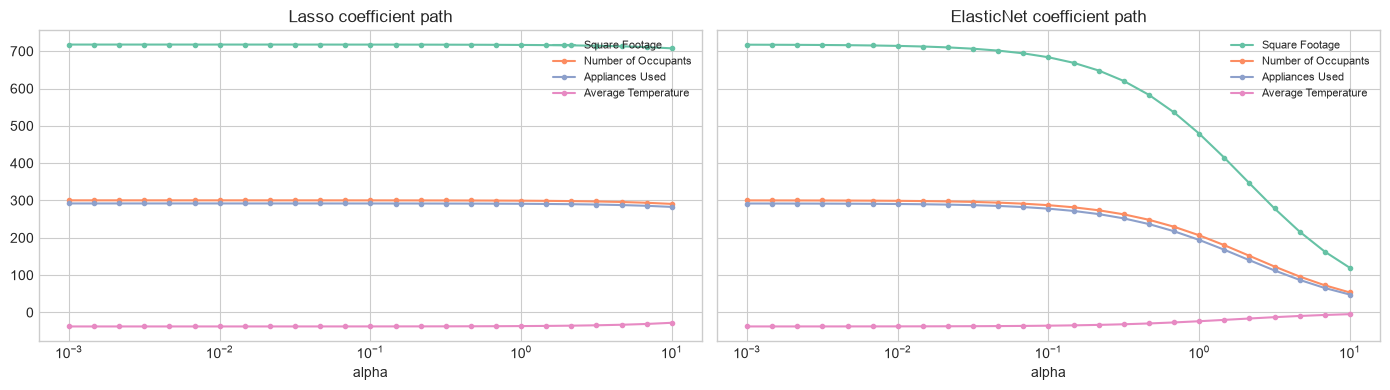

In [10]:
alphas = np.logspace(-3, 1, 25)
path_rows = []
for alpha in alphas:
    lasso = LassoRegressionCustom(alpha=alpha, max_iter=5000, tol=1e-7).fit(X_train_sc, y_train)
    enet = ElasticNetCustom(alpha=alpha, l1_ratio=0.5, max_iter=5000, tol=1e-7).fit(X_train_sc, y_train)
    for feature, coef in zip(energy_features, lasso.coef_):
        path_rows.append({'model': 'Lasso', 'alpha': alpha, 'feature': feature, 'coefficient': coef})
    for feature, coef in zip(energy_features, enet.coef_):
        path_rows.append({'model': 'ElasticNet', 'alpha': alpha, 'feature': feature, 'coefficient': coef})

path_df = pd.DataFrame(path_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, model_name in zip(axes, ['Lasso', 'ElasticNet']):
    subset = path_df[path_df['model'] == model_name]
    for feature in energy_features:
        feature_path = subset[subset['feature'] == feature]
        ax.plot(feature_path['alpha'], feature_path['coefficient'], marker='o', ms=3, label=feature)
    ax.set_xscale('log')
    ax.set_title(f'{model_name} coefficient path')
    ax.set_xlabel('alpha')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Regularized Logistic Regression on EnergyTypeNet

For classification, regularization controls the size of logistic-regression weights. This section compares no penalty, L1, L2 and ElasticNet penalties on the building-type task.

In [11]:
classification_features = ['Energy Consumption', 'Square Footage']
label_map = {'Residential': 0, 'Commercial': 1, 'Industrial': 2}
X = train_df[classification_features].to_numpy(float)
y = train_df['Building Type'].map(label_map).to_numpy(int)
X_holdout = test_df[classification_features].to_numpy(float)
y_holdout = test_df['Building Type'].map(label_map).to_numpy(int)
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
X_holdout_sc = scaler.transform(X_holdout)

rows = []
for penalty, l1_ratio in [('none', None), ('l1', None), ('l2', None), ('elasticnet', 0.5)]:
    model = RegularizedLogisticRegression(
        penalty=penalty, C=1.0, l1_ratio=l1_ratio, learning_rate=0.01,
        n_iterations=2000, random_state=RANDOM_STATE
    )
    model.fit(X_sc, y)
    pred = model.predict(X_holdout_sc)
    rows.append({
        'penalty': penalty,
        'holdout_accuracy': accuracy_score(y_holdout, pred),
        'nonzero_weights': int(np.sum(np.abs(model.weights_) > 1e-4)),
        'final_loss': model.loss_history_[-1],
    })

pd.DataFrame(rows).sort_values('holdout_accuracy', ascending=False)

,penalty,holdout_accuracy,nonzero_weights,final_loss
0,none,0.61,6,0.516995
2,l2,0.51,6,0.626355
1,l1,0.40,5,0.645498
3,elasticnet,0.40,6,0.639635


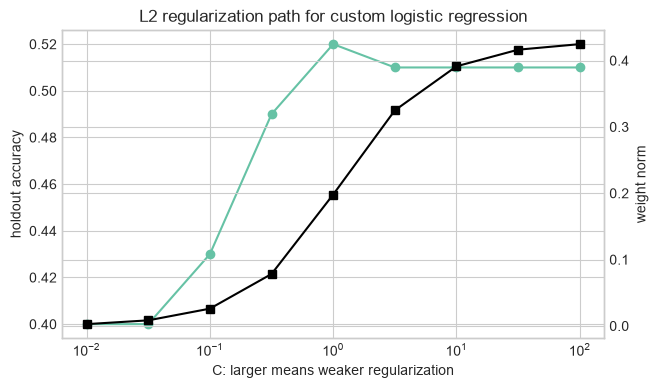

,C,holdout_accuracy,weight_norm
0,0.010000,0.40,0.002658
1,0.031623,0.40,0.008361
2,0.100000,0.43,0.025999
3,0.316228,0.49,0.078221
4,1.000000,0.52,0.198036
5,3.162278,0.51,0.324858
6,10.000000,0.51,0.391281
7,31.622777,0.51,0.416308
8,100.000000,0.51,0.424687


In [12]:
C_values = np.logspace(-2, 2, 9)
path_rows = []
for C in C_values:
    model = RegularizedLogisticRegression(
        penalty='l2', C=C, learning_rate=0.001, n_iterations=2000, random_state=RANDOM_STATE
    )
    model.fit(X_sc, y)
    path_rows.append({
        'C': C,
        'holdout_accuracy': accuracy_score(y_holdout, model.predict(X_holdout_sc)),
        'weight_norm': float(np.linalg.norm(model.weights_)),
    })
path_cls = pd.DataFrame(path_rows)
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(path_cls['C'], path_cls['holdout_accuracy'], marker='o')
ax1.set_xscale('log')
ax1.set_xlabel('C: larger means weaker regularization')
ax1.set_ylabel('holdout accuracy')
ax2 = ax1.twinx()
ax2.plot(path_cls['C'], path_cls['weight_norm'], marker='s', color='black')
ax2.set_ylabel('weight norm')
plt.title('L2 regularization path for custom logistic regression')
plt.show()
path_cls

## Observation: Regularized logistic regression

For the two-feature building-type classification task, the unregularized custom logistic model performs best on the holdout set (`accuracy = 0.61`). Stronger L1, L2 and ElasticNet penalties reduce weight size, but they also underfit this already limited feature space. The C-path confirms the trade-off: very small `C` values impose strong regularization and low accuracy, while weaker regularization increases the weight norm and improves accuracy until it levels off.

## 6. Practical Guide

| Method | Penalty | Best use | Risk |
| --- | --- | --- | --- |
| Ridge | L2 | Many correlated numeric predictors | Keeps all features, so it is less sparse |
| Lasso | L1 | Feature selection and compact models | Can pick one feature from a correlated group arbitrarily |
| ElasticNet | L1 + L2 | Correlated predictors with desired sparsity | Requires tuning both alpha and l1_ratio |
| Regularized logistic regression | L1/L2/ElasticNet | Classification with controlled weight growth | Too much regularization can underfit |

**Main takeaway:** regularization is not only an accuracy tool. It also controls model complexity, improves stability and makes the feature story easier to explain.

In [13]:
summary = pd.DataFrame([
    {'model': 'RidgeRegressionCustom', 'task': 'regression', 'custom': True, 'regularization': 'L2'},
    {'model': 'LassoRegressionCustom', 'task': 'regression', 'custom': True, 'regularization': 'L1'},
    {'model': 'ElasticNetCustom', 'task': 'regression', 'custom': True, 'regularization': 'L1 + L2'},
    {'model': 'RegularizedLogisticRegression', 'task': 'classification', 'custom': True, 'regularization': 'none / L1 / L2 / ElasticNet'},
    {'model': 'sklearn Ridge/Lasso/ElasticNet', 'task': 'regression', 'custom': False, 'regularization': 'reference implementations'},
])
summary

,model,task,custom,regularization
0,RidgeRegressionCustom,regression,True,L2
1,LassoRegressionCustom,regression,True,L1
2,ElasticNetCustom,regression,True,L1 + L2
3,RegularizedLogisticRegression,classification,True,none / L1 / L2 / ElasticNet
4,sklearn Ridge/Lasso/ElasticNet,regression,False,reference implementations
